# Chapter 7 — How to Picture Neural Networks: In Your Head and on Paper

**Grokking Deep Learning — Andrew W. Trask**


> Chapter ini memang berfokus pada **cara memvisualisasikan dan menyederhanakan neural network**, bukan memperkenalkan training experiment baru. Karena itu, visual utama di notebook ini menggunakan **diagram arsitektur, diagram alur signal, representasi vector–matrix, dan tabel dimensi**, bukan heatmap yang tidak membantu memahami konsep.

## Learning Objectives

Setelah menyelesaikan Chapter 7, kita diharapkan dapat:

- memahami **correlation summarization**;
- membedakan **local** dan **global correlation summarization**;
- menyederhanakan neural network dari koneksi antar-node menjadi **vectors dan matrices**;
- memahami hubungan ukuran layer dengan ukuran weight matrix;
- mengikuti forward propagation melalui visual yang lebih sederhana;
- membaca representasi neural network menggunakan simbol `l0`, `l1`, `l2`, `W0`, dan `W1`;
- menghubungkan **visualization → algebra → Python code**.

## Chapter Roadmap

Chapter 7 mengikuti alur:

**Complex neural network → Correlation summarization → Simplified architecture → Vector & matrix representation → Algebra → Python**

Buku menekankan bahwa semakin kompleks network, kita tidak perlu terus menggambar setiap weight satu per satu. Kita perlu mempertahankan informasi penting tentang **shape, layer, matrix, dan aliran signal**.

## 1. It’s Time to Simplify

Chapter 6 berakhir dengan neural network yang sudah cukup padat. Chapter 7 tidak menambah architecture baru; fokusnya adalah membuat **mental model** yang lebih efisien.

Gagasan utama buku:

> Daripada mengingat setiap neuron dan setiap weight, kita dapat menyimpan konsep yang lebih ringkas: neural network mencari dan membuat **correlation** antara input layer dan output layer.

## 2. Correlation Summarization

**Correlation summarization** adalah cara ringkas untuk memahami apa yang dilakukan neural network.

Buku merangkumnya sebagai:

**Neural network mencari direct dan indirect correlation antara input layer dan output layer.**

Jadi banyak konsep sebelumnya — neurons, gradients, layers, weight updates, dan backpropagation — dapat dilihat sebagai bagian dari proses menemukan atau membuat correlation.

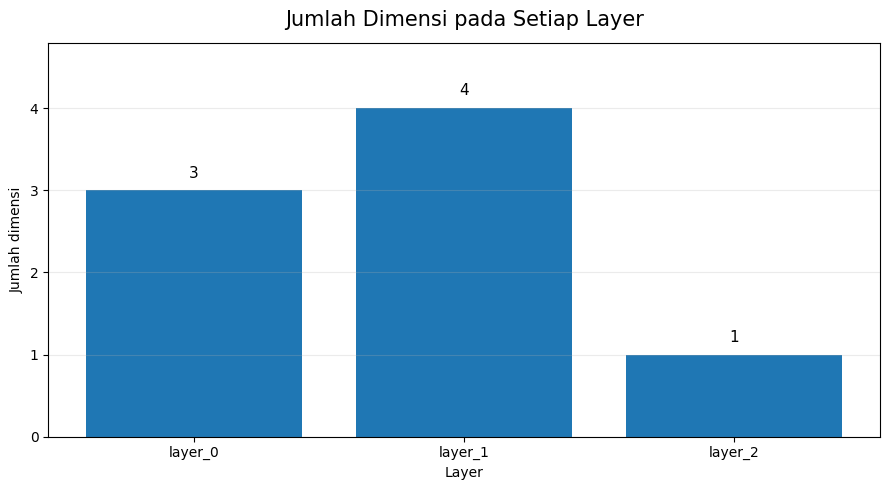

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Dimensi layer yang digunakan pada contoh Chapter 7.
layer_dimensions = {
    "layer_0": 3,
    "layer_1": 4,
    "layer_2": 1
}

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(layer_dimensions.keys(), layer_dimensions.values())
ax.set_title("Jumlah Dimensi pada Setiap Layer", fontsize=15, pad=12)
ax.set_ylabel("Jumlah dimensi")
ax.set_xlabel("Layer")
ax.set_ylim(0, 4.8)
ax.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, layer_dimensions.values()):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.12, str(value),
            ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()


Chart sebelumnya menggunakan angka yang memang diberikan pada contoh Chapter 7. Untuk bagian yang hanya bersifat konseptual, notebook tidak membuat angka tambahan agar visual tetap akurat terhadap sumber.

## 3. Local vs Global Correlation Summarization

Chapter ini membedakan dua sudut pandang:

### Local correlation summarization
Satu set weight mengoptimalkan hubungan antara **input layer** dengan signal yang diminta oleh layer berikutnya.

### Global correlation summarization
Layer yang lebih akhir dapat memberi tahu layer sebelumnya signal seperti apa yang dibutuhkan. Informasi tersebut diteruskan melalui weight menggunakan **backpropagation**.

Buku menggunakan analogi **giant game of telephone**: layer akhir memberi informasi ke layer sebelumnya, kemudian diteruskan lagi ke layer yang lebih awal.

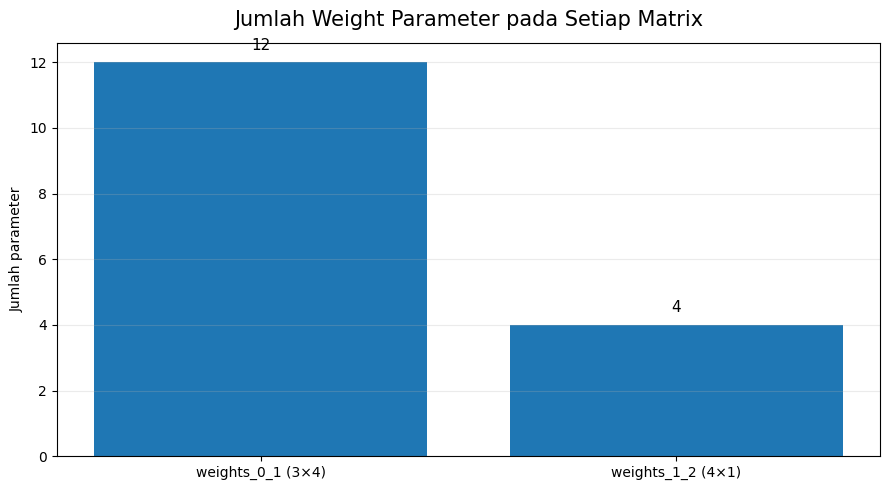

In [ ]:
# Perbandingan jumlah komponen yang perlu dipikirkan:
# individual weights pada matrix vs. representasi matrix sebagai satu komponen.
# Nilai parameter dihitung dari shape matrix yang diberikan buku.

matrix_parameters = {
    "weights_0_1 (3×4)": 3 * 4,
    "weights_1_2 (4×1)": 4 * 1
}

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(matrix_parameters.keys(), matrix_parameters.values())
ax.set_title("Jumlah Weight Parameter pada Setiap Matrix", fontsize=15, pad=12)
ax.set_ylabel("Jumlah parameter")
ax.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, matrix_parameters.values()):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.3, str(value),
            ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()


## 4. The Previously Overcomplicated Visualization

Sebelumnya, kita dapat menggambar setiap node dan setiap weight sebagai garis.

Cara ini berguna ketika pertama kali belajar, tetapi akan cepat menjadi sulit dibaca ketika sebuah layer memiliki banyak node.

Buku kemudian mengubah cara berpikir:

- **strip of nodes → vector**
- **connections between nodes → matrix**
- individual weight values tidak perlu selalu ditampilkan.

In [ ]:
# Tidak ada chart pada bagian ini karena sumber hanya menjelaskan
# masalah visual node-by-node secara konseptual, tanpa data numerik.
# Informasi tersebut diringkas pada markdown berikutnya.
print("Node-by-node visualization → detail tinggi, tetapi semakin sulit dibaca saat jumlah node bertambah.")


Node-by-node visualization → detail tinggi, tetapi semakin sulit dibaca saat jumlah node bertambah.


### Mengapa perlu disederhanakan?

Bayangkan `layer_1` memiliki ratusan node. Menggambar seluruh garis weight akan membuat visual penuh dan sulit dibaca.

Karena itu, Chapter 7 mengganti detail tersebut dengan **vector dan matrix** yang tetap mempertahankan informasi struktural.

## 5. The Simplified Visualization

Buku menggunakan analogi **LEGO bricks**:

- strip = **vector**
- box = **matrix**
- circles / numbers = individual values atau weights

Yang penting bukan lagi posisi setiap garis, tetapi **shape dan hubungan antar komponen**.

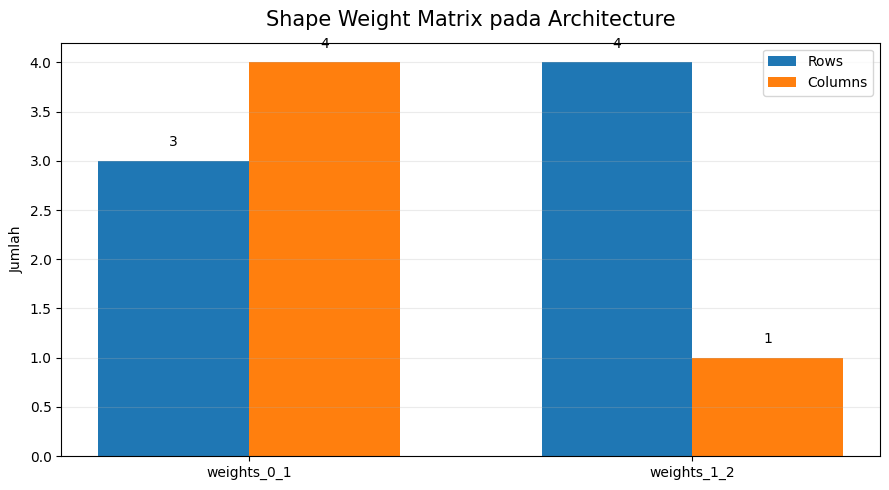

In [ ]:
# Shape matrix yang diberikan pada sumber.
# Chart ini menampilkan baris dan kolom sebagai ukuran struktural matrix.

matrix_shapes = {
    "weights_0_1": (3, 4),
    "weights_1_2": (4, 1)
}

labels = list(matrix_shapes.keys())
rows = [v[0] for v in matrix_shapes.values()]
cols = [v[1] for v in matrix_shapes.values()]

x = np.arange(len(labels))
width = 0.34

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, rows, width, label="Rows")
bars2 = ax.bar(x + width/2, cols, width, label="Columns")

ax.set_title("Shape Weight Matrix pada Architecture", fontsize=15, pad=12)
ax.set_ylabel("Jumlah")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis="y", alpha=0.25)

for bars in (bars1, bars2):
    for bar in bars:
        value = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, value + 0.12, f"{int(value)}",
                ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


### Dimensi yang diberikan buku

Untuk architecture Chapter 6:

| Komponen | Shape |
|---|---:|
| `layer_0` | `1 × 3` |
| `weights_0_1` | `3 × 4` |
| `layer_1` | `1 × 4` |
| `weights_1_2` | `4 × 1` |
| `layer_2` | `1 × 1` |

Hubungan ini memungkinkan kita mengetahui shape matrix hanya dari ukuran layer sebelum dan sesudahnya. Buku secara eksplisit menggunakan `weights_0_1` berukuran **3 × 4** sebagai contoh.

In [ ]:
# Cek dimensionality menggunakan shape yang benar-benar dipakai network Chapter 6
layer_0_shape = (1, 3)
weights_0_1_shape = (3, 4)
layer_1_shape = (1, 4)
weights_1_2_shape = (4, 1)
layer_2_shape = (1, 1)

shapes = [
    ("layer_0", layer_0_shape),
    ("weights_0_1", weights_0_1_shape),
    ("layer_1", layer_1_shape),
    ("weights_1_2", weights_1_2_shape),
    ("layer_2", layer_2_shape),
]

for name, shape in shapes:
    print(f"{name:14s}: {shape}")

layer_0       : (1, 3)
weights_0_1   : (3, 4)
layer_1       : (1, 4)
weights_1_2   : (4, 1)
layer_2       : (1, 1)


## 6. Matrix Dimension Rule

Inti visual di bagian ini:

**jumlah kolom matrix = jumlah dimensi output layer**

dan

**jumlah baris matrix = jumlah dimensi input layer**

Contoh:

`layer_0 (1 × 3) · weights_0_1 (3 × 4) → layer_1 (1 × 4)`

Kemudian:

`layer_1 (1 × 4) · weights_1_2 (4 × 1) → layer_2 (1 × 1)`

Ini adalah cara yang jauh lebih mudah untuk mengecek apakah sebuah architecture memiliki dimensi yang valid.

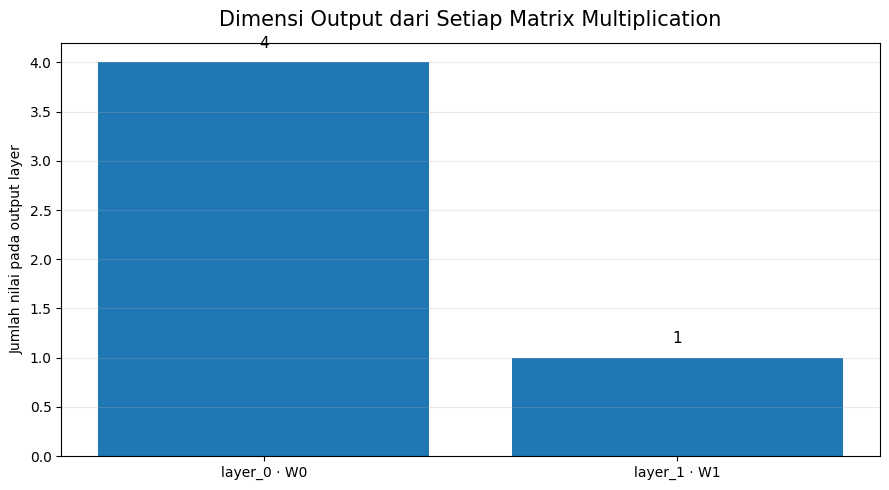

In [ ]:
# Validasi dimensionality berdasarkan aturan vector–matrix multiplication.
# Semua angka berasal dari shape yang digunakan pada contoh Chapter 7.

operations = [
    "layer_0 · W0",
    "layer_1 · W1"
]
output_dimensions = [4, 1]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(operations, output_dimensions)
ax.set_title("Dimensi Output dari Setiap Matrix Multiplication", fontsize=15, pad=12)
ax.set_ylabel("Jumlah nilai pada output layer")
ax.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, output_dimensions):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.12, str(value),
            ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()


## 7. Let’s See This Network Predict

Buku kemudian memperlihatkan satu data streetlight mengalir melalui network.

Contoh input:

`layer_0 = [1, 0, 1]`

Empat weighted sums dibuat melalui `weights_0_1`, lalu hasilnya melewati ReLU. Pada figure buku, nilai hidden layer yang ditampilkan adalah:

`[0.5, 0.2, 0, 0.9]`

Nilai ketiga menjadi `0` karena hasil sebelum ReLU bernilai negatif.

Kemudian layer berikutnya melakukan weighted sum dan buku menunjukkan **final prediction = 0.9**.

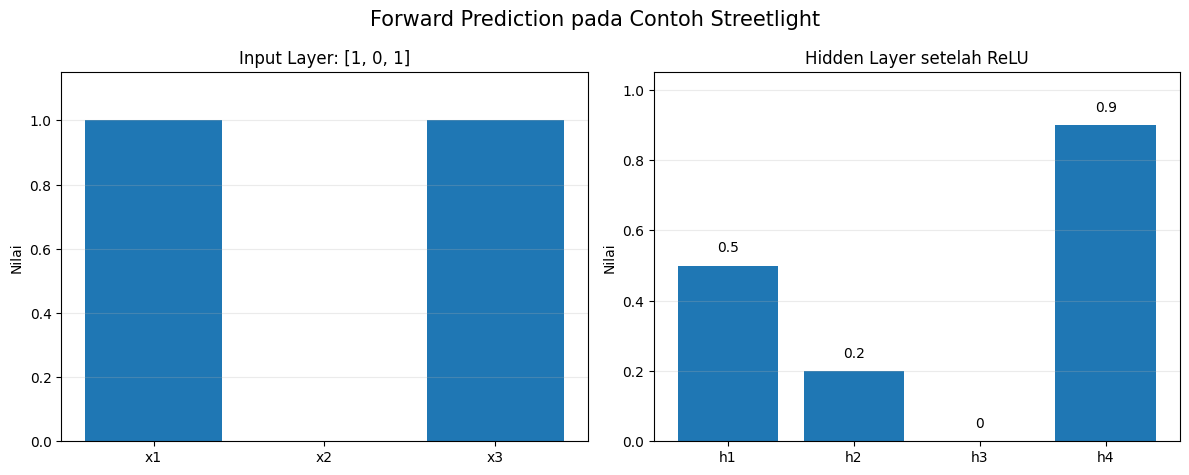

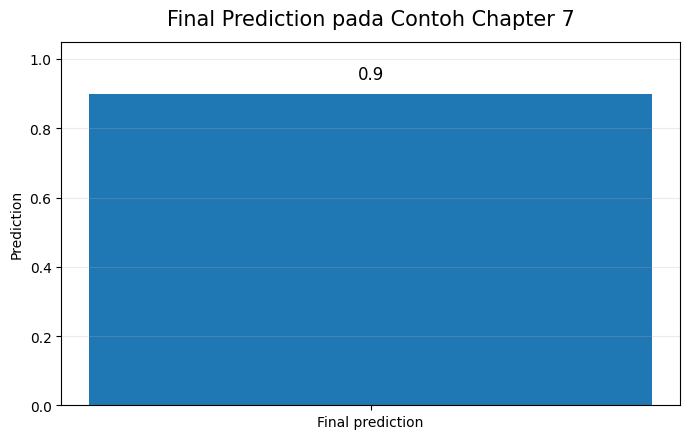

In [ ]:
# Nilai yang ditampilkan secara eksplisit pada contoh prediksi Chapter 7.
input_values = [1, 0, 1]
hidden_values = [0.5, 0.2, 0.0, 0.9]
final_prediction = 0.9

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].bar(["x1", "x2", "x3"], input_values)
axes[0].set_title("Input Layer: [1, 0, 1]")
axes[0].set_ylabel("Nilai")
axes[0].set_ylim(0, 1.15)
axes[0].grid(axis="y", alpha=0.25)

bars = axes[1].bar(["h1", "h2", "h3", "h4"], hidden_values)
axes[1].set_title("Hidden Layer setelah ReLU")
axes[1].set_ylabel("Nilai")
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis="y", alpha=0.25)

for bar, value in zip(bars, hidden_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, value + 0.03, f"{value:g}",
                 ha="center", va="bottom", fontsize=10)

plt.suptitle("Forward Prediction pada Contoh Streetlight", fontsize=15)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
bar = ax.bar(["Final prediction"], [final_prediction])
ax.set_title("Final Prediction pada Contoh Chapter 7", fontsize=15, pad=12)
ax.set_ylabel("Prediction")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.25)
ax.text(bar[0].get_x() + bar[0].get_width()/2, final_prediction + 0.03,
        f"{final_prediction:g}", ha="center", va="bottom", fontsize=12)
plt.tight_layout()
plt.show()


> **Akurasi data:** chart di atas hanya menggunakan nilai yang secara eksplisit ditampilkan pada contoh Chapter 7: input `[1, 0, 1]`, hidden values `[0.5, 0.2, 0, 0.9]`, dan final prediction `0.9`.

## 8. Vector–Matrix Multiplication

Buku mengingatkan kembali bahwa vector–matrix multiplication melakukan beberapa **weighted sums** sekaligus.

Jika vector mempunyai 3 nilai dan matrix mempunyai 4 kolom, maka akan dihasilkan **4 weighted sums**.

Itulah alasan:

`layer_0 (1 × 3) · weights_0_1 (3 × 4)`

menghasilkan:

`layer_1 (1 × 4)`

In [ ]:
# Demonstrasi shape dengan operasi NumPy yang sama seperti konsep buku
layer_0 = np.array([[1.0, 0.0, 1.0]])

# Matrix ini hanya dipakai untuk menunjukkan aturan shape.
# Nilai weight bukan diklaim sebagai angka dari figure Chapter 7.
demo_weights = np.array([
    [0.2, 0.1, -0.3, 0.4],
    [0.1, 0.5,  0.2, 0.1],
    [0.3, 0.2,  0.1, 0.6],
])

weighted_sums = np.dot(layer_0, demo_weights)

print("layer_0 shape:", layer_0.shape)
print("weights shape:", demo_weights.shape)
print("result shape:", weighted_sums.shape)
print("result:", weighted_sums.ravel())

layer_0 shape: (1, 3)
weights shape: (3, 4)
result shape: (1, 4)
result: [ 0.5  0.3 -0.2  1. ]


**Penting:** operasi NumPy di atas hanya mendemonstrasikan **dimensionality**, bukan mereproduksi nilai prediction `0.9` dari figure buku. Karena sumber yang digunakan di sini tidak memberikan seluruh nilai matrix numeriknya, notebook tidak mengarang matrix lalu mengklaim hasilnya sebagai output buku.

## 9. Visualizing Using Letters Instead of Pictures

Setelah vector dan matrix dipahami, buku menggantinya dengan simbol:

- `W0` = weight matrix pertama
- `W1` = weight matrix kedua
- `l0` = layer 0 vector
- `l1` = layer 1 vector
- `l2` = layer 2 vector

Buku memilih `W` karena mudah diingat sebagai **weights**, dan `l` sebagai representasi **layers**.

In [ ]:
# Representasi simbol yang digunakan buku.
symbols = {
    "W0": "weight matrix pertama",
    "W1": "weight matrix kedua",
    "l0": "layer 0 vector",
    "l1": "layer 1 vector",
    "l2": "layer 2 vector"
}
for symbol, meaning in symbols.items():
    print(f"{symbol:>2} → {meaning}")


W0 → weight matrix pertama
W1 → weight matrix kedua
l0 → layer 0 vector
l1 → layer 1 vector
l2 → layer 2 vector


## 10. Linking the Variables

Buku kemudian menghubungkan simbol tersebut dengan operasi.

### Operasi pertama

`l1 = relu(l0W0)`

Artinya:
> ambil `layer 0`, lakukan vector–matrix multiplication dengan `W0`, lalu gunakan ReLU.

### Operasi kedua

`l2 = l1W1`

Artinya:
> ambil `layer 1`, lalu lakukan vector–matrix multiplication dengan `W1`.

Keduanya dapat digabung menjadi:

`l2 = relu(l0W0)W1`

In [ ]:
# Forward propagation dalam notasi aljabar yang digunakan buku.
equations = [
    "l1 = relu(l0W0)",
    "l2 = l1W1",
    "l2 = relu(l0W0)W1"
]
for equation in equations:
    print(equation)


l1 = relu(l0W0)
l2 = l1W1
l2 = relu(l0W0)W1


## 11. Everything Side by Side

Salah satu tujuan Chapter 7 adalah membuat kita dapat melihat satu proses yang sama dari beberapa perspektif:

| Perspektif | Representasi |
|---|---|
| Architecture | `layer_0 → layer_1 → layer_2` |
| Matrix/vector | `l0 → W0 → l1 → W1 → l2` |
| Algebra | `l2 = relu(l0W0)W1` |
| Python | `layer_2 = relu(layer_0.dot(weights_0_1)).dot(weights_1_2)` |

Buku menempatkan keempat cara tersebut berdampingan agar forward propagation benar-benar dapat dipahami dari beberapa sudut.

In [ ]:
# Empat perspektif untuk proses forward propagation.
perspectives = [
    ("Architecture", "layer_0 → layer_1 → layer_2"),
    ("Vector / Matrix", "l0 → W0 → l1 → W1 → l2"),
    ("Algebra", "l2 = relu(l0W0)W1"),
    ("Python", "layer_2 = relu(layer_0.dot(weights_0_1)).dot(weights_1_2)")
]
for name, representation in perspectives:
    print(f"{name}: {representation}")


Architecture: layer_0 → layer_1 → layer_2
Vector / Matrix: l0 → W0 → l1 → W1 → l2
Algebra: l2 = relu(l0W0)W1
Python: layer_2 = relu(layer_0.dot(weights_0_1)).dot(weights_1_2)


## 12. Architecture as a Signal-Flow Design

Chapter 7 mulai mengarahkan perhatian ke konsep **architecture**.

Architecture adalah konfigurasi layer dan weight matrix yang menentukan bagaimana signal mengalir.

Buku menekankan:

**Good architecture → channel signal so correlation is easier to discover**

**Great architecture → channel signal + filter noise to reduce overfitting**

Jadi architecture bukan sekadar gambar network; ia memengaruhi kemampuan network untuk menemukan correlation.

In [ ]:
# Kesimpulan konseptual dari bagian architecture.
print("Good architecture  → channel signal so correlation is easier to discover")
print("Great architecture → channel signal + filter noise to help prevent overfitting")


Good architecture  → channel signal so correlation is easier to discover
Great architecture → channel signal + filter noise to help prevent overfitting


## 13. The Importance of Visualization Tools

Buku menutup chapter dengan alasan praktis: chapter berikutnya dan chapter setelahnya akan memperkenalkan berbagai architecture.

Agar architecture baru mudah dipahami, kita membutuhkan bahasa visual yang sama:

**vector + matrix + layer + signal flow**

Dengan cara ini, kita tidak perlu menggambar setiap individual weight untuk memahami bagaimana sebuah architecture bekerja.

## Concept Check

| Pertanyaan | Jawaban |
|---|---|
| Apa itu correlation summarization? | Cara ringkas melihat neural network sebagai pencari direct/indirect correlation antara input dan output |
| Apa itu local correlation summarization? | Weight set mengoptimalkan correlation secara lokal |
| Apa itu global correlation summarization? | Signal kebutuhan layer berikutnya diteruskan ke layer sebelumnya melalui backpropagation |
| Mengapa visual node-by-node disederhanakan? | Terlalu detail ketika jumlah node besar |
| Apa pengganti node-by-node? | Vector dan matrix |
| Shape `weights_0_1`? | `3 × 4` untuk `layer_0` 3-dimensi dan `layer_1` 4-dimensi |
| Apa arti `W0`? | Weight matrix pertama |
| Apa arti `l0`? | Layer 0 vector |
| Rumus forward propagation? | `l2 = relu(l0W0)W1` |
| Mengapa architecture penting? | Menentukan bagaimana signal dialirkan sehingga correlation lebih mudah ditemukan |

## Key Takeaways

1. Jangan mencoba menyimpan seluruh detail neural network di kepala sekaligus.
2. **Correlation summarization** menjadi mental model utama.
3. Neural network dapat dipandang sebagai **vectors yang dihubungkan oleh matrices**.
4. Shape matrix mengikuti dimensi layer sebelum dan sesudahnya.
5. `l1 = relu(l0W0)` dan `l2 = l1W1` dapat digabung menjadi `l2 = relu(l0W0)W1`.
6. Visualization, algebra, dan Python sebenarnya menggambarkan **operasi yang sama**.
7. Architecture menentukan bagaimana signal mengalir dan memengaruhi kemampuan menemukan correlation.
8. Visual yang baik harus menyederhanakan kompleksitas **tanpa membuang informasi struktural yang penting**.

## Chapter Summary

Chapter 7 bukan tentang menambah algoritma baru. Chapter ini mengajarkan **cara melihat neural network**.

Kita bergerak dari:

**individual nodes & weights**

menjadi:

**vectors & matrices**

lalu menjadi:

**algebraic notation**

dan akhirnya kembali ke:

**Python implementation**

Tujuannya adalah agar architecture yang lebih kompleks pada chapter berikutnya tetap dapat dipahami tanpa harus menggambar setiap koneksi individual.

## Reference

Trask, A. W. *Grokking Deep Learning*. Manning Publications.

**Chapter 7 — How to Picture Neural Networks: In Your Head and on Paper**

Bagian yang dibahas:
- It’s Time to Simplify
- Correlation Summarization
- The Previously Overcomplicated Visualization
- The Simplified Visualization
- Simplifying Even Further
- Let’s See This Network Predict
- Visualizing Using Letters Instead of Pictures
- Linking the Variables
- Everything Side by Side
- The Importance of Visualization Tools

**Catatan:** angka dan contoh numerik pada notebook diambil dari contoh yang ditampilkan pada Chapter 7. Untuk konsep yang tidak memiliki data numerik, penjelasan menggunakan teks atau tabel agar tidak membuat angka ilustratif yang dapat disalahartikan sebagai hasil sumber.
